# Практическая работа по Apache Hive

## Описание

В рамках практической работы была развёрнута среда Apache Hive в Docker и выполнены основные операции по работе с таблицами различных типов.

## Выполненные этапы

### 1. Развёртывание инфраструктуры
Был развёрнут Docker-стек на базе репозитория `docker-hive`, включающий следующие компоненты:
- Hive Server
- Hive Metastore
- PostgreSQL (в качестве хранилища метаданных)
- Hadoop NameNode и DataNode

### 2. Работа с внешней таблицей (External Table)
- Загружен датасет аэропортов (`airports.csv`) в HDFS
- Создана внешняя таблица `airports` в базе данных `osipov_db`
- Таблица настроена на чтение CSV-файла с пропуском заголовка
- Выполнена проверка корректности загрузки данных

### 3. Создание Managed-таблицы
- На основе внешней таблицы создана управляемая (Managed) таблица `airports_orc` в формате **ORC**
- После создания внешней таблицы она была удалена
- Подтверждено, что данные Managed-таблицы сохранились в HDFS

### 4. Партиционирование
- Создана партиционированная таблица `airports_orc_part` с партиционированием по полю `type`
- Включены настройки динамических партиций
- Данные успешно загружены с автоматическим созданием партиций
- Получены следующие партиции:
  - `balloonport`
  - `closed`
  - `heliport`
  - `large_airport`
  - `medium_airport`
  - `seaplane_base`
  - `small_airport`

### 5. Бакетирование
- Создана таблица `airports_orc_bucketed` с бакетированием по полю `ident` на **3 бакета**
- Данные загружены в таблицу
- На HDFS подтверждено наличие трёх файлов-бакетов (`000000_0`, `000001_0`, `000002_0`)

### 6. Работа с Metastore
- Выполнена проверка содержимого Metastore (таблица `TBLS` в PostgreSQL)
- Удалена бакетированная таблица
- Подтверждено, что запись о таблице исчезла как из Metastore, так и из HDFS

### 7. DML и аналитические запросы
Выполнены различные запросы:
- Выборка крупных аэропортов (`large_airport`) с сортировкой по высоте (возрастание/убывание)
- Группировка по континентам с подсчётом количества аэропортов
- Расчёт средней высоты аэропортов по континентам
- Фильтрация результатов по условию средней высоты

## Использованные технологии

- Apache Hive 2.3.2
- Hadoop 2.7.4
- PostgreSQL (Metastore)
- Docker & Docker Compose
- Форматы хранения: TEXTFILE, ORC

In [1]:
# git clone https://github.com/big-data-europe/docker-hive.git
# cd docker-hive

# docker-compose up -d --scale presto-coordinator=0

# docker-compose ps

# docker-compose exec hive-server bash

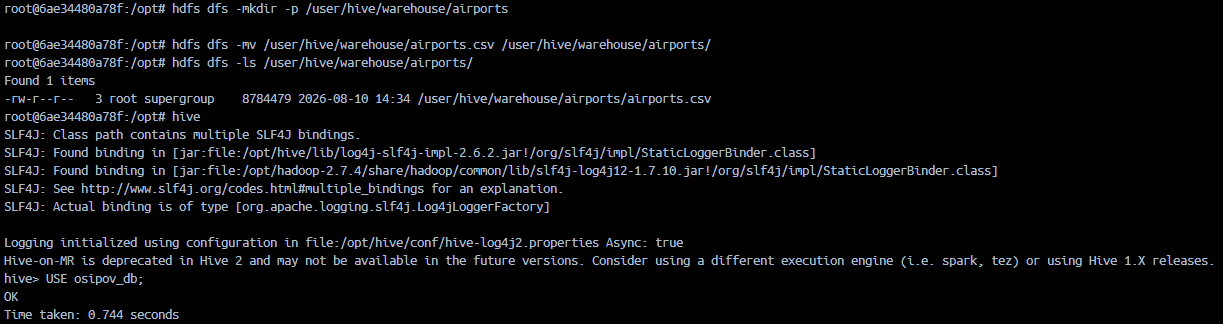

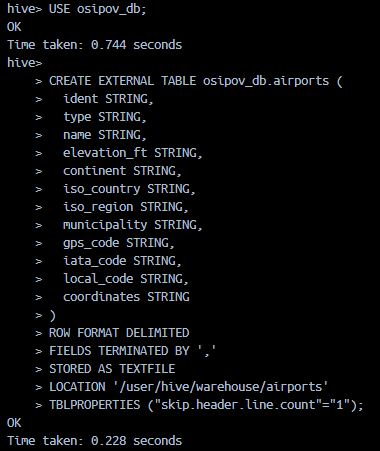

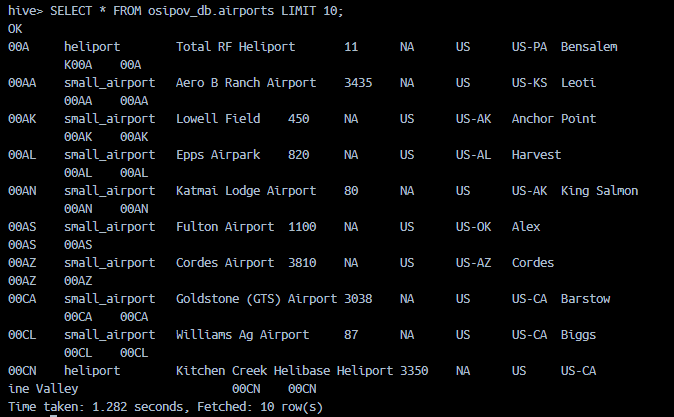

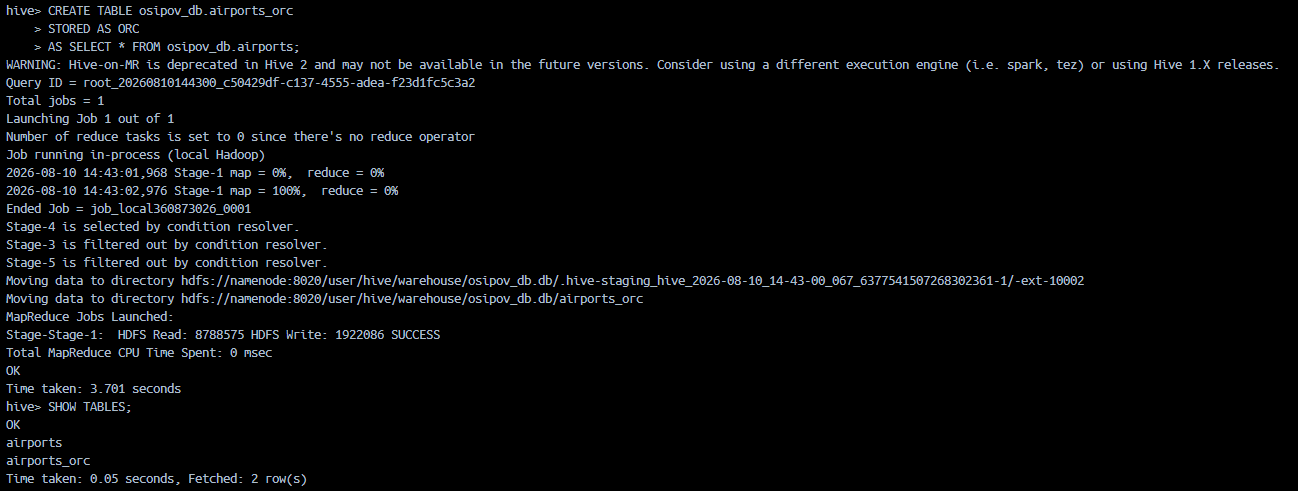

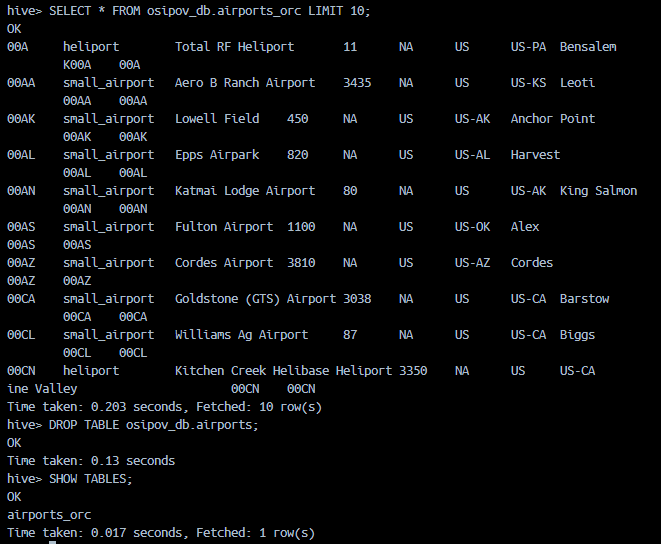

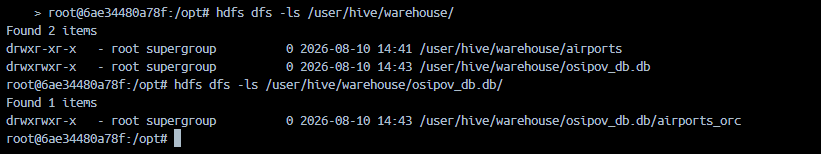

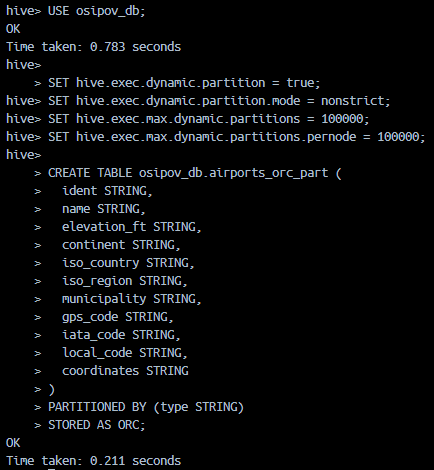

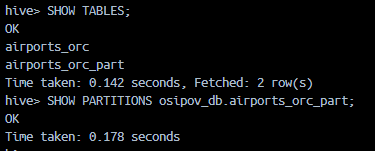

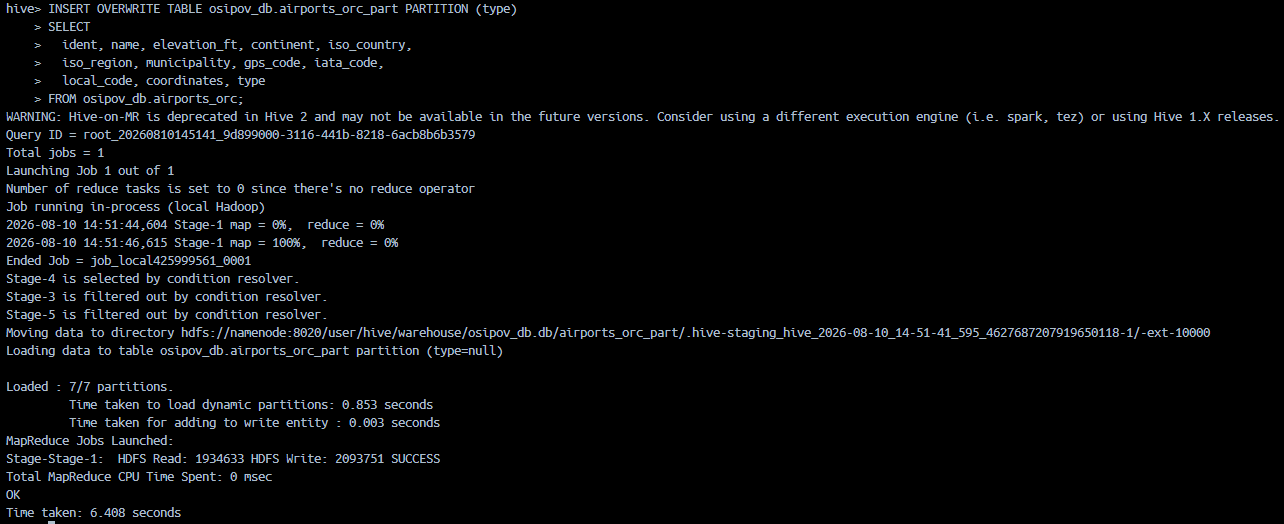

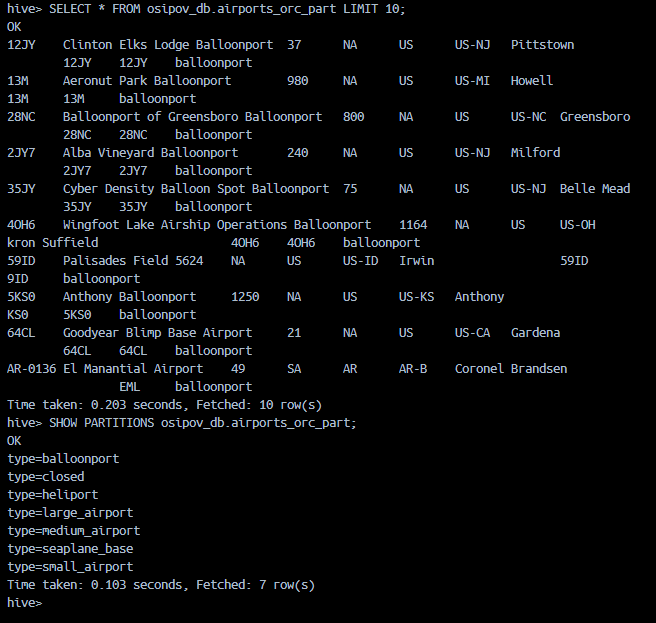

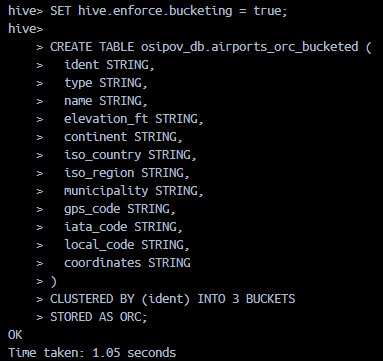

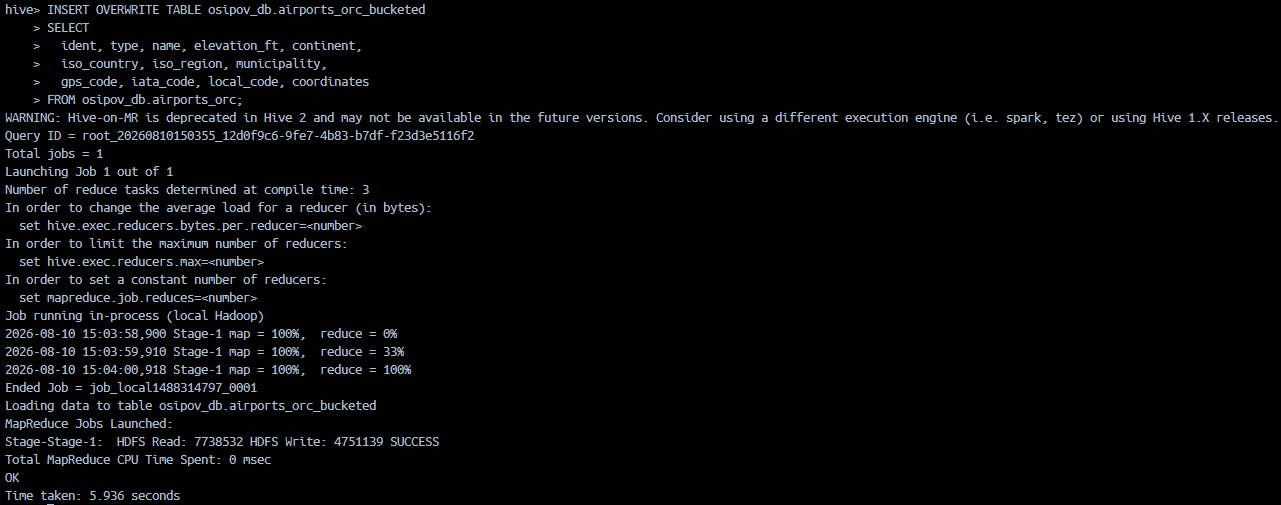

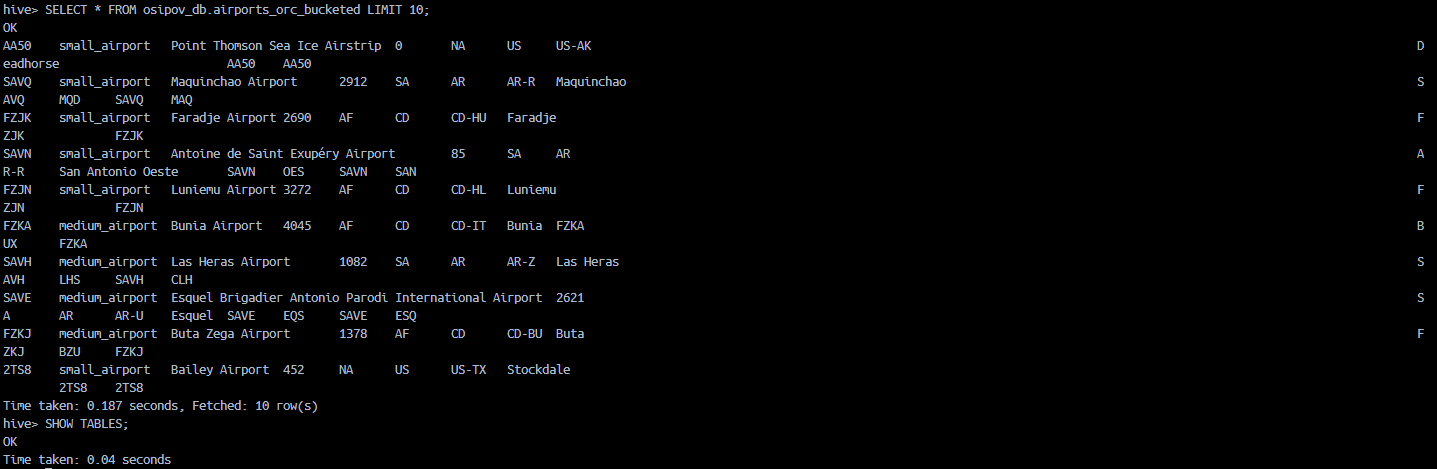

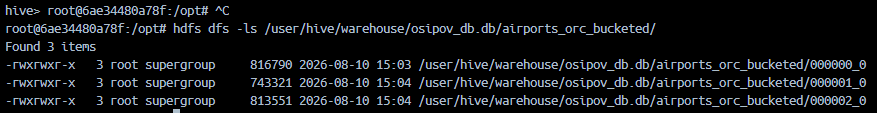

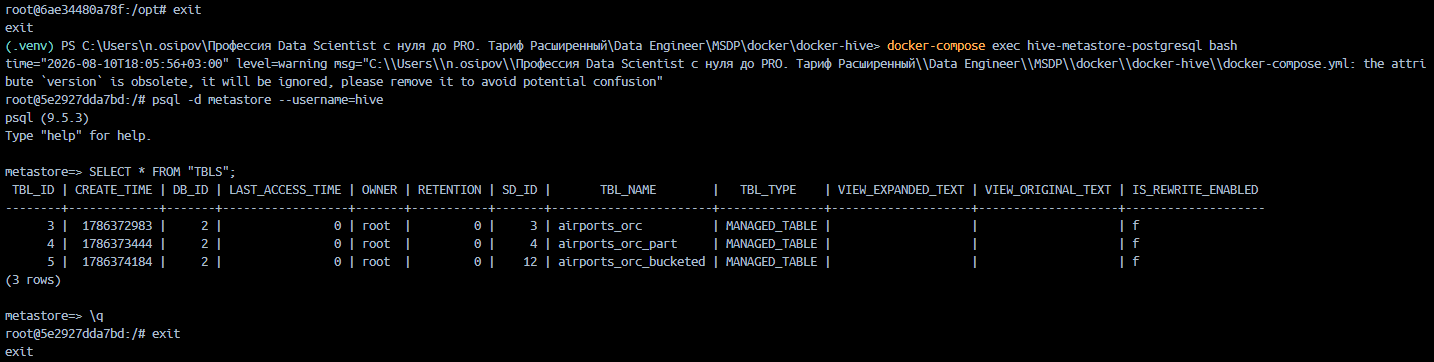

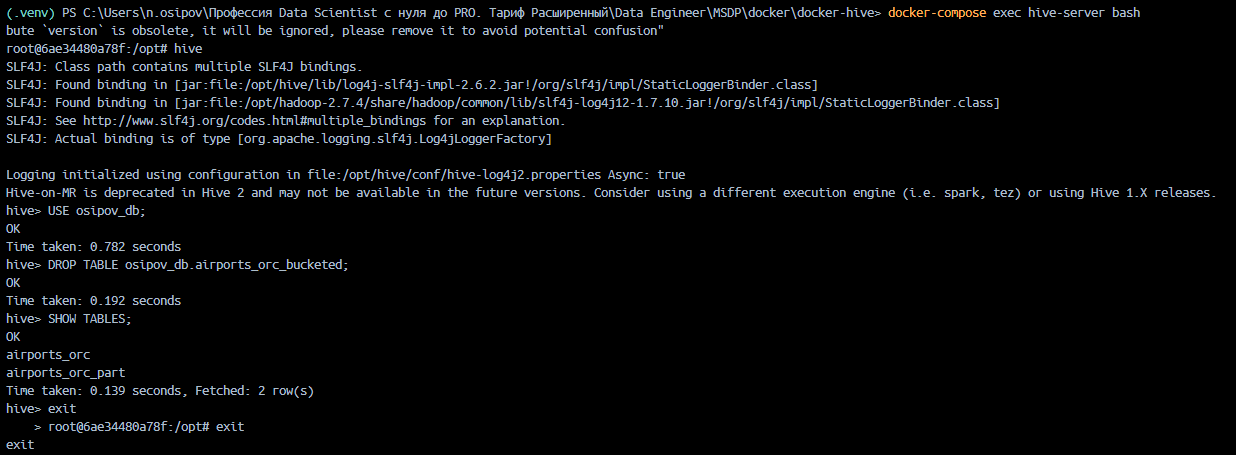

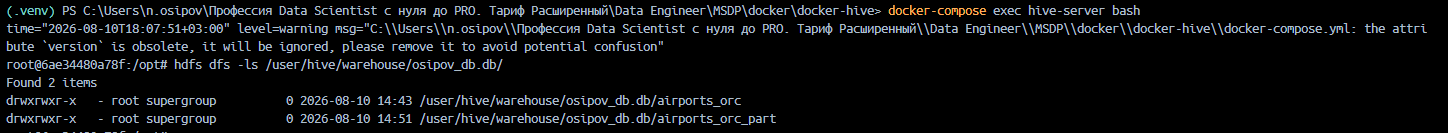

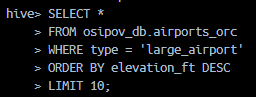

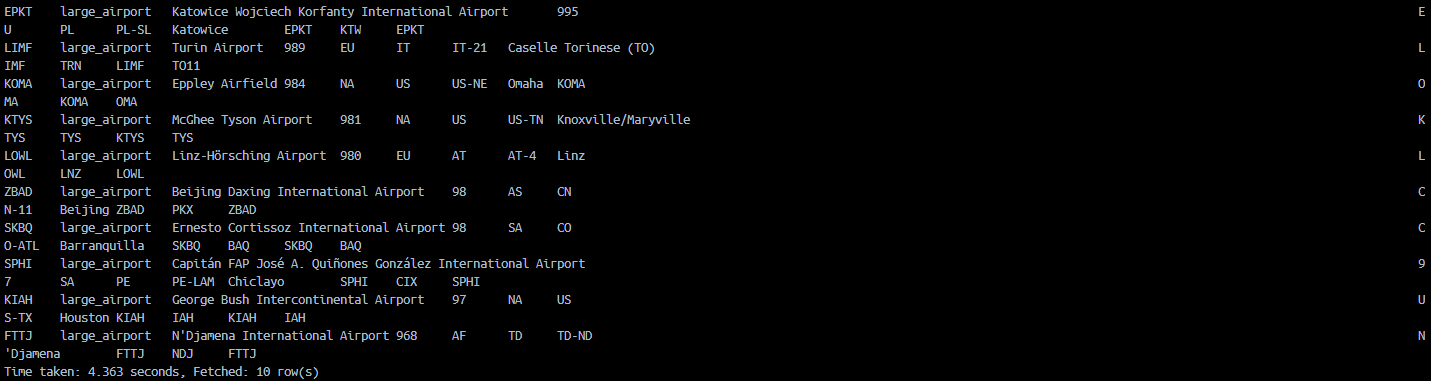

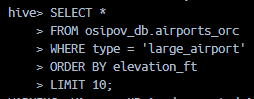

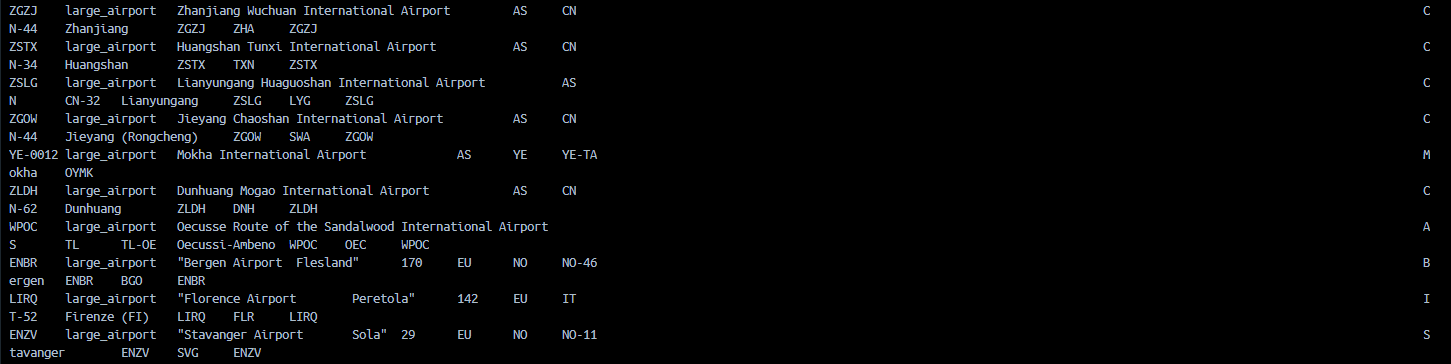

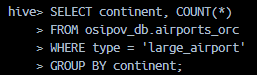

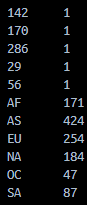

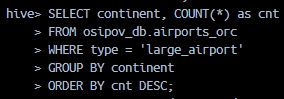

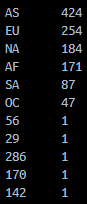

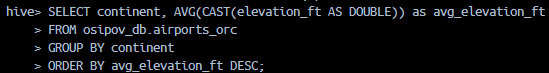

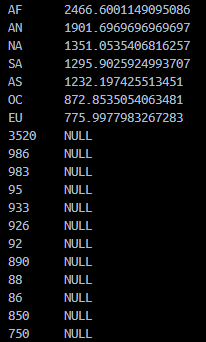